# Sentinel-1 Level-0 → Focused SLC (Stripmap/S6)


Processing flow:

`L0 → raw decoding → I/Q correction → range compression → Doppler centroid → effective velocity → azimuth FFT → SRC → RCMC → azimuth compression → SLC`

## 1 - Imports and input file

### 1.1 - Imports

In [1]:
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import sentinel1decoder

import sentinel1_processing.doppler_centroid_estimation as doppler_centroid_estimation
import sentinel1_processing.dce_plotting as dce_plotting
import sentinel1_processing.effective_velocity as effective_velocity
import sentinel1_processing.range_processing as range_processing
import sentinel1_processing.raw_data_correction as raw_data_correction
import sentinel1_processing.azimuth_pre_processing as azimuth_pre_processing
import sentinel1_processing.azimuth_processing as azimuth_processing

notebook_started_at = perf_counter()
pd.set_option("display.max_columns", None)


### 1.2 - Input product

In [2]:
filepath = "./data/sao_paulo/"
filename = "s1a-s6-raw-s-vv-20251226t214356-20251226t214427-062491-07d496.dat"

inputfile = filepath + filename
l0file = sentinel1decoder.Level0File(inputfile)


## 2 - Metadata and acquisition chunk

### 2.1 - Packet metadata

In [3]:
l0file.packet_metadata


Packet Version Number  Packet Type  \
Acquisition Chunk Packet Number                                       
0                 0                                  0            0   
                  1                                  0            0   
                  2                                  0            0   
                  3                                  0            0   
                  4                                  0            0   
...                                                ...          ...   
27                50701                              0            0   
                  50702                              0            0   
                  50703                              0            0   
                  50704                              0            0   
                  50705                              0            0   

                                 Secondary Header Flag  PID  PCAT  \
Acquisition Chunk Packet Number                                     
0                 0                                  1   65    12   
                  1                                  1   65    12   
                  2                                  1   65    12   
                  3                                  1   65    12   
                  4                                  1   65    12   
...                                                ...  ...   ...   
27                50701                              1   65    12   
                  50702                              1   65    12   
                  50703                              1   65    12   
                  50704                              1   65    12   
                  50705                              1   65    12   

                                 Sequence Flags  Packet Sequence Count  \
Acquisition Chunk Packet Number                                          
0                 0                           3                      0   
                  1                           3                      1   
                  2                           3                      2   
                  3                           3                      3   
                  4                           3                      4   
...                                         ...                    ...   
27                50701                       3                   1549   
                  50702                       3                   1550   
                  50703                       3                   1551   
                  50704                       3                   1552   
                  50705                       3                   1553   

                                 Packet Data Length  Coarse Time  Fine Time  \
Acquisition Chunk Packet Number                                               
0                 0                           25086   1450820654   0.593239   
                  1                           25086   1450820654   0.593834   
                  2                           25086   1450820654   0.594444   
                  3                           25086   1450820654   0.595039   
                  4                           25086   1450820654   0.595650   
...                                             ...          ...        ...   
27                50701                       25126   1450820685   0.228447   
                  50702                       25126   1450820685   0.229057   
                  50703                       25126   1450820685   0.229652   
                  50704                       25126   1450820685   0.230247   
                  50705                       25126   1450820685   0.230858   

                                      Sync  Data Take ID  \
Acquisition Chunk Packet Number                            
0                 0              892270675     262745280   
                  1              8922706

### 2.2 - Orbit records

In [4]:
l0file.ephemeris


,X-axis position ECEF,Y-axis position ECEF,Z-axis position ECEF,X-axis velocity ECEF,Y-axis velocity ECEF,Z-axis velocity ECEF,POD Solution Data Timestamp,Q0 Attitude Quaternion,Q1 Attitude Quaternion,Q2 Attitude Quaternion,Q3 Attitude Quaternion,Omega-X Angular Rate,Omega-Y Angular Rate,Omega-Z Angular Rate,Attitude Data Timestamp
0,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
1,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
2,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
3,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
4,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
758,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
759,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
760,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09


### 2.3 - Acquisition chunk

In [5]:
selected_chunk = 13

selection = l0file.get_acquisition_chunk_metadata(selected_chunk)
selection


,Packet Version Number,Packet Type,Secondary Header Flag,PID,PCAT,Sequence Flags,Packet Sequence Count,Packet Data Length,Coarse Time,Fine Time,Sync,Data Take ID,ECC Number,Test Mode,Rx Channel ID,Instrument Configuration ID,Sub-commutated Ancilliary Data Word Index,Sub-commutated Ancilliary Data Word,Space Packet Count,PRI Count,Error Flag,BAQ Mode,BAQ Block Length,Range Decimation,Rx Gain,Tx Ramp Rate,Tx Pulse Start Frequency,Tx Pulse Length,Rank,PRI,SWST,SWL,SAS SSB Flag,Polarisation,Temperature Compensation,Elevation Beam Address,Azimuth Beam Address,SAS Test Mode,Cal Type,Calibration Beam Address,Calibration Mode,Tx Pulse Number,Signal Type,Swap Flag,Swath Number,Number of Quads
Packet Number,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
408,0,0,1,65,12,3,408,14514,1450820654,0.910637,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,25,48627,408,3826,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
409,0,0,1,65,12,3,409,14678,1450820654,0.911247,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,26,37203,409,3827,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
410,0,0,1,65,12,3,410,14622,1450820654,0.911842,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,27,48895,410,3828,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
411,0,0,1,65,12,3,411,14662,1450820654,0.912437,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,28,53525,411,3829,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
412,0,0,1,65,12,3,412,14606,1450820654,0.913048,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,29,48671,412,3830,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30337,0,0,1,65,12,3,13953,13098,1450820672,0.902458,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,30,65245,30337,33755,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
30338,0,0,1,65,12,3,13954,13106,1450820672,0.903069,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,31,14385,30338,33756,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
30339,0,0,1,65,12,3,13955,13114,1450820672,0.903664,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,32,46065,30339,33757,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975


## 3 - Raw signal decoding (DAD §9.1)

Decode the selected acquisition chunk into the complex I/Q matrix used by the Level-1 processing chain.

### 3.1 - Decode I/Q data

In [6]:
radar_data = l0file.get_acquisition_chunk_data(selected_chunk)

len_az_line, raw_len_range_line = radar_data.shape

print("Raw data shape:", radar_data.shape)


Raw data shape: (29934, 19950)


### 3.2 - Raw data view

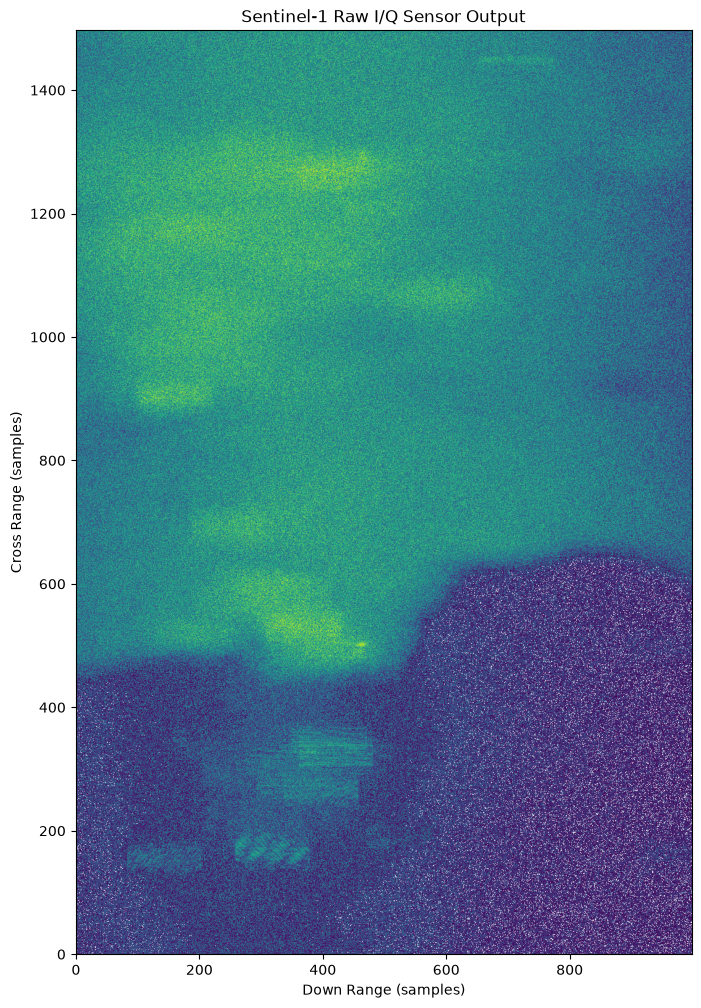

In [7]:
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Raw I/Q Sensor Output")
plt.imshow(
    np.abs(radar_data[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm()
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


### 3.3 - Input I/Q correction (DAD §9.2.1)

Estimate the complex DC bias from the raw echo data before matched filtering.

In [8]:
iq_bias = raw_data_correction.estimate_iq_bias(radar_data)


## 4 - Sampling axes (DAD §9.9)

Build the range and azimuth time bases used by the processing chain.

### 4.1 - Radar and acquisition constants

In [9]:
c = sentinel1decoder.constants.SPEED_OF_LIGHT_MPS
wavelength_m = sentinel1decoder.constants.TX_WAVELENGTH_M

RGDEC = selection["Range Decimation"].iloc[0]
PRI = selection["PRI"].iloc[0]
rank = selection["Rank"].iloc[0]
TXPSF = selection["Tx Pulse Start Frequency"].iloc[0]
TXPRR = selection["Tx Ramp Rate"].iloc[0]
TXPL = selection["Tx Pulse Length"].iloc[0]


### 4.2 - Sampling frequencies

Calculate the range sampling frequency and azimuth PRF from the metadata.

In [10]:
range_sample_freq = sentinel1decoder.utilities.range_dec_to_sample_rate(RGDEC)
range_sample_period = 1.0 / range_sample_freq
az_sample_freq = 1.0 / PRI
az_sample_period = PRI
suppressed_data_time = 320.0 / (8.0 * sentinel1decoder.constants.F_REF)


### 4.3 - Slant-range grid

Build the fast-time, slant-range time, and slant-range distance axes.

In [11]:
range_start_time = selection["SWST"].iloc[0] + suppressed_data_time
raw_fast_time_vec_s = (
    range_start_time + np.arange(raw_len_range_line) / range_sample_freq
)
raw_slant_range_time_vec_s = rank * PRI + raw_fast_time_vec_s
raw_slant_range_vec_m = raw_slant_range_time_vec_s * c / 2.0


### 4.4 - Azimuth-time grid

Combine packet coarse and fine times on the GPS time base.

In [12]:
packet_azimuth_times_s = (
    selection["Coarse Time"].to_numpy(dtype=float)
    + selection["Fine Time"].to_numpy(dtype=float)
)


### 4.5 - Sampling summary

In [13]:
sampling_summary = pd.Series({
    "range_samples": raw_len_range_line,
    "range_sample_frequency_mhz": range_sample_freq / 1e6,
    "azimuth_lines": len_az_line,
    "prf_hz": az_sample_freq,
    "slant_range_near_km": raw_slant_range_vec_m[0] / 1e3,
    "slant_range_far_km": raw_slant_range_vec_m[-1] / 1e3,
    "azimuth_start_gps_s": packet_azimuth_times_s[0],
    "azimuth_stop_gps_s": packet_azimuth_times_s[-1],
})
display(sampling_summary.to_frame("value"))


,value
range_samples,1.995000e+04
range_sample_frequency_mhz,4.691840e+01
azimuth_lines,2.993400e+04
prf_hz,1.663478e+03
slant_range_near_km,9.137528e+02
slant_range_far_km,9.774864e+02
azimuth_start_gps_s,1.450821e+09
azimuth_stop_gps_s,1.450821e+09


> **Time base:** packet and ephemeris timestamps are GPS seconds. UTC annotation timestamps require the GPS–UTC offset.

## 5 - Range Processing (DAD §6.1)

Steps: Range Reference Function → range dependent gain correction → SWST bias correction.

### 5.1 - Range Reference Function (DAD §6.1.1)

Calculate the matched filter in the range-frequency domain.

In [14]:
tx_replica_sample_count = int(np.ceil(TXPL * range_sample_freq))
range_fft_length = 1 << int(np.ceil(np.log2(
    raw_len_range_line + tx_replica_sample_count - 1
)))
range_reference_function = range_processing.reference_function.calculate(
    sample_rate_hz=range_sample_freq,
    pulse_start_frequency_hz=TXPSF,
    pulse_ramp_rate_hz_per_s=TXPRR,
    pulse_length_s=TXPL,
    fft_length=range_fft_length,
)
print(tx_replica_sample_count)
print(range_fft_length)


2398
32768


### 5.2 - Range Dependent Gain Correction (DAD §6.1.2)

`range_processing.dependent_gain.apply()` is available when the gain vector is supplied. This dataset does not include that vector.

### 5.3 - SWST Bias Correction (DAD §6.1.3)

In [15]:
# From references/s1a-aux-ins.xml: internalCalibrationParams/swstBias.
SWST_BIAS_S = -8.2256909e-9

raw_slant_range_time_vec_s = range_processing.swst_bias.correct(
    raw_slant_range_time_vec_s, SWST_BIAS_S
)


## 6 - Azimuth Pre-Processing (DAD §6.2)
- Input: An azimuth block of range-compressed data in 2D time domain.
- Output: Data in range-Doppler domain, which is the required input for the next stage, azimuth processing
- Stripmap S6 steps: azimuth zero-padding → range compression → forward azimuth FFT. 

### 6.1 - Azimuth Zero-Padding (DAD §6.2.1)

`azimuth_pre_processing.azimuth_zero_padding.apply()` pads each processing block to the FFT length.

### 6.2 - Range Compression (DAD §6.2.2)

`azimuth_pre_processing.range.compression` exposes `zero_pad()`, `forward_fft()`, `multiply_reference_function()`, `inverse_fft()`, and `extract_valid_samples()`. `compress()` runs them in order.

In [16]:
range_compressed, slant_range_time_vec_s = (
    azimuth_pre_processing.range.compression.compress(
        radar_data,
        raw_slant_range_time_vec_s,
        sample_rate_hz=range_sample_freq,
        pulse_start_frequency_hz=TXPSF,
        pulse_ramp_rate_hz_per_s=TXPRR,
        pulse_length_s=TXPL,
        iq_bias=iq_bias,
        range_reference_function=range_reference_function,
    )
)


#### Valid Range Samples

In [17]:
slant_range_vec_m = slant_range_time_vec_s * c / 2.0
len_range_line = range_compressed.shape[1]
del radar_data

pd.Series({
    "iq_bias": iq_bias,
    "range_compressed_shape": range_compressed.shape,
    "valid_range_samples": len_range_line,
})


iq_bias                   (0.27753220566213055+0.3119490645637209j)
range_compressed_shape                               (29934, 17553)
valid_range_samples                                           17553
dtype: object

#### Range-compressed data

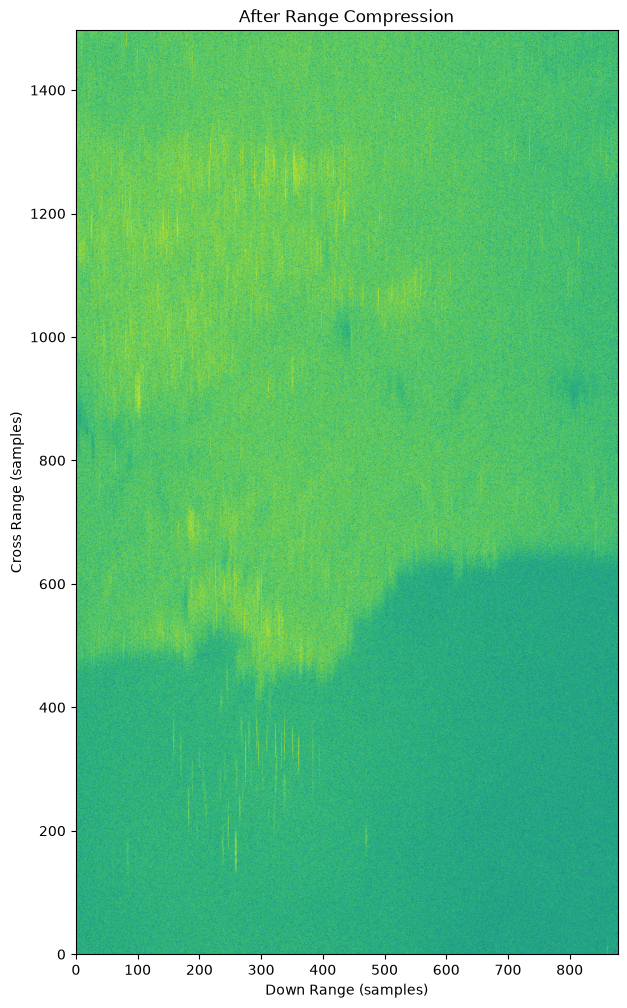

In [18]:
plt.figure(figsize=(12, 12))
plt.title("After Range Compression")
plt.imshow(
    np.abs(range_compressed[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm()
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


### 6.3 - Azimuth Forward FFT (DAD §6.2.3)

`azimuth_pre_processing.azimuth_forward_fft.apply()` transforms each padded block to the range-Doppler domain during focusing.

## 7 - Doppler Centroid Estimation (DAD §5)

Estimate Doppler centroid from range-compressed data. Annotation polynomials are used only for comparison.

### 7.1 - Annotation records

These Level-1 annotation polynomials are validation references; they are not inputs to focusing.

In [19]:
DOPPLER_CENTROID_ANNOTATIONS = doppler_centroid_estimation.parse_annotation_records([
    {
        "azimuthTime": "2025-12-26T21:43:59.100490",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": [4.152910e+01, 1.012491e+05, -4.252661e+08],
        "fineStart": "2025-12-26T21:43:57.297041",
        "fineStop": "2025-12-26T21:44:00.903940",
    },
    {
        "azimuthTime": "2025-12-26T21:44:14.095877",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": [1.141131e+01, 1.275731e+04, 6.579813e+07],
        "fineStart": "2025-12-26T21:44:12.292428",
        "fineStop": "2025-12-26T21:44:15.899327",
    },
    {
        "azimuthTime": "2025-12-26T21:44:25.484967",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": [3.263240e+01, -2.579159e+03, -1.314992e+08],
        "fineStart": "2025-12-26T21:44:23.681518",
        "fineStop": "2025-12-26T21:44:27.288417",
    },
])


### 7.2 - Input segments (DAD §5.6)

Load the adjacent acquisition chunk because the middle Doppler-estimation interval crosses the chunk boundary.

In [20]:
ZERO_DOPPLER_MINUS_ACQ_TIME_S = 0.386295160  # Scene timing offset.
DOPPLER_CENTROID_T0_S = DOPPLER_CENTROID_ANNOTATIONS[0]["t0"]

doppler_centroid_chunk = selected_chunk + 1
metadata_14 = l0file.get_acquisition_chunk_metadata(doppler_centroid_chunk)
radar_data_14 = l0file.get_acquisition_chunk_data(doppler_centroid_chunk)


#### Time axes for chunk 14

In [21]:
raw_range_count_14 = radar_data_14.shape[1]
range_start_time_14 = metadata_14["SWST"].iloc[0] + suppressed_data_time
raw_slant_range_time_14 = (
    metadata_14["Rank"].iloc[0] * metadata_14["PRI"].iloc[0]
    + range_start_time_14
    + np.arange(raw_range_count_14) / range_sample_freq
)
raw_slant_range_time_14 = range_processing.swst_bias.correct(
    raw_slant_range_time_14, SWST_BIAS_S
)
packet_azimuth_times_14 = (
    metadata_14["Coarse Time"].to_numpy(dtype=float)
    + metadata_14["Fine Time"].to_numpy(dtype=float)
)


### 7.3 - Prepare the adjacent segment

Apply the same I/Q correction and range-compression settings before joining both segments on a common grid.

In [22]:
iq_bias_14 = raw_data_correction.estimate_iq_bias(radar_data_14)
range_compressed_14, slant_range_time_14 = (
    azimuth_pre_processing.range.compression.compress(
        radar_data_14,
        raw_slant_range_time_14,
        sample_rate_hz=range_sample_freq,
        pulse_start_frequency_hz=TXPSF,
        pulse_ramp_rate_hz_per_s=TXPRR,
        pulse_length_s=TXPL,
        iq_bias=iq_bias_14,
    )
)
del radar_data_14


### 7.4 - Doppler centroid estimation (DAD §§5.2–5.5)

Estimate fine Doppler, unwrap it, resolve PRF ambiguity when geometry Doppler is available, and fit the range polynomial.

In [23]:
doppler_centroid_segments = [
    doppler_centroid_estimation.Segment(
        range_compressed,
        slant_range_time_vec_s,
        packet_azimuth_times_s,
        name="chunk13",
    ),
    doppler_centroid_estimation.Segment(
        range_compressed_14,
        slant_range_time_14,
        packet_azimuth_times_14,
        name="chunk14",
    ),
]


#### Doppler centroid time interval

In [24]:
scene_start_acq_s = packet_azimuth_times_s[0]
scene_stop_acq_s = packet_azimuth_times_14[-1] + PRI
doppler_centroid_estimator = doppler_centroid_estimation.Estimator.for_stripmap_s6(
    prf_hz=az_sample_freq
)


#### Estimate Doppler centroid

In [25]:
doppler_centroid_estimates, doppler_centroid_scene = doppler_centroid_estimator.estimate_segments(
    doppler_centroid_segments,
    t0_s=DOPPLER_CENTROID_T0_S,
    slice_start_times_s=[scene_start_acq_s],
    last_slice_stop_time_s=scene_stop_acq_s,
    product_start_time_s=(
        scene_start_acq_s + ZERO_DOPPLER_MINUS_ACQ_TIME_S
    ),
    product_stop_time_s=(
        scene_stop_acq_s + ZERO_DOPPLER_MINUS_ACQ_TIME_S
    ),
    zero_dop_minus_acq_time_s=ZERO_DOPPLER_MINUS_ACQ_TIME_S,
    return_prepared_scene=True,
)


#### Segment alignment

In [26]:
alignment_summary = pd.DataFrame(doppler_centroid_scene.alignment_summary())
display(alignment_summary)
print("Estimated Doppler centroid records:", len(doppler_centroid_estimates))


,name,global_start_line,global_stop_line,azimuth_lines,native_range_samples,common_range_samples,native_range_start_s,common_range_start_s,source_start_index,integer_shift_samples,fractional_part_samples,range_spacing_s
0,chunk13,0,29934,29934,17553,17553,0.006121,0.006121,0.00,0,0.00,2.131360e-08
1,chunk14,29934,49890,19956,17589,17553,0.006120,0.006121,81.25,81,0.25,2.131360e-08


Estimated Doppler centroid records: 3


### 7.5 - Doppler centroid for each processing block

Return the fitted Doppler centroid at each block center. Annotation data is not used here.

In [27]:
def doppler_centroid_for_block(block_center_index):
    return doppler_centroid_estimator.evaluate_at_line(
        doppler_centroid_estimates,
        line_index=block_center_index,
        azimuth_times_s=packet_azimuth_times_s,
        slant_range_times_s=slant_range_time_vec_s,
        azimuth_time_offset_s=ZERO_DOPPLER_MINUS_ACQ_TIME_S,
    )

# Release temporary chunk-14 arrays.
del doppler_centroid_segments, doppler_centroid_scene, range_compressed_14


### 7.6 - Polynomial comparison

Compare estimated and annotation polynomials. Report time error, RMSE, coherence, and PRF ambiguity.

In [28]:
doppler_centroid_comparisons = doppler_centroid_estimation.compare_with_annotations(
    DOPPLER_CENTROID_ANNOTATIONS,
    doppler_centroid_estimates,
    slant_range_time_vec_s,
    prf_hz=az_sample_freq,
)


#### Error table

In [29]:
comparison_rows = []
for result in doppler_centroid_comparisons:
    comparison_rows.append({
        "record": result["record"],
        "annotation_coefficients": result["annotation_coefficients"],
        "estimated_coefficients": result["estimated_coefficients"],
        "azimuth_time_error_ms": result["azimuth_time_error_ms"],
        "bias_hz": result["bias_hz"],
        "rmse_hz": result["rmse_hz"],
        "max_abs_error_hz": result["max_abs_error_hz"],
        "integer_prf_adjustment_hz": result["integer_prf_adjustment_hz"],
        "fit_rms_hz": result["fit_rms_hz"],
        "mean_coherence": result["mean_coherence"],
        "absolute_ambiguity_resolved": result["absolute_ambiguity_resolved"],
    })

doppler_centroid_accuracy = pd.DataFrame(comparison_rows).set_index("record")
display(doppler_centroid_accuracy)


,annotation_coefficients,estimated_coefficients,azimuth_time_error_ms,bias_hz,rmse_hz,max_abs_error_hz,integer_prf_adjustment_hz,fit_rms_hz,mean_coherence,absolute_ambiguity_resolved
record,,,,,,,,,,
1,"[41.5291, 101249.1, -425266100.0]","[39.84982229512738, 60290.70926769855, -246968...",-0.106573,-0.249249,4.205398,10.427333,0.0,3.075953,0.283507,False
2,"[11.41131, 12757.31, 65798130.0]","[10.88442943208967, 14501.803510248874, 438760...",0.203609,-1.402409,1.639664,3.330783,0.0,3.177374,0.418913,False
3,"[32.6324, -2579.159, -131499200.0]","[30.231203780619257, 19828.171411950098, -1627...",-0.097036,0.583346,1.189013,1.849453,-0.0,1.116509,0.411453,False


#### Doppler centroid curves

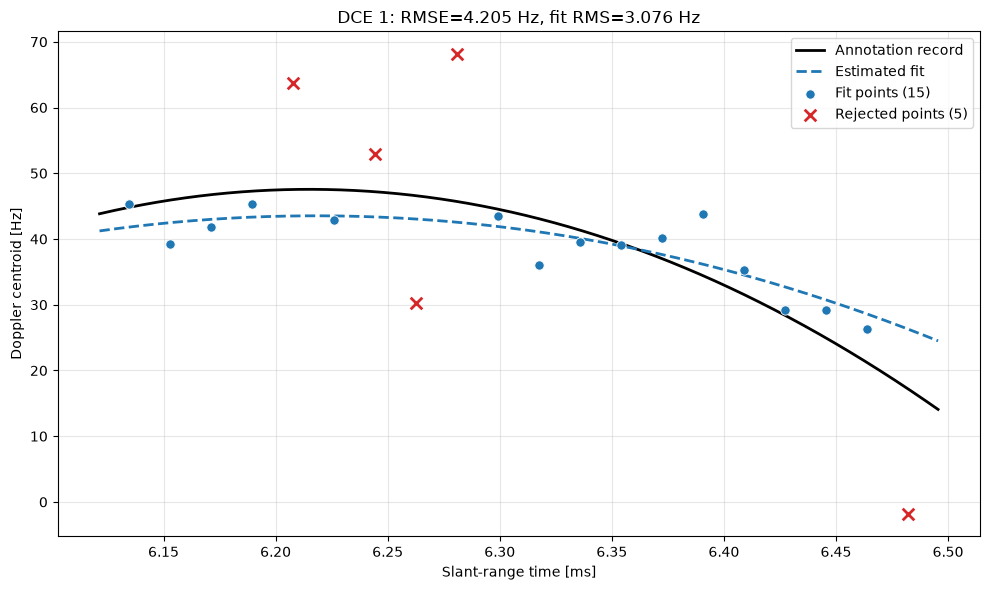

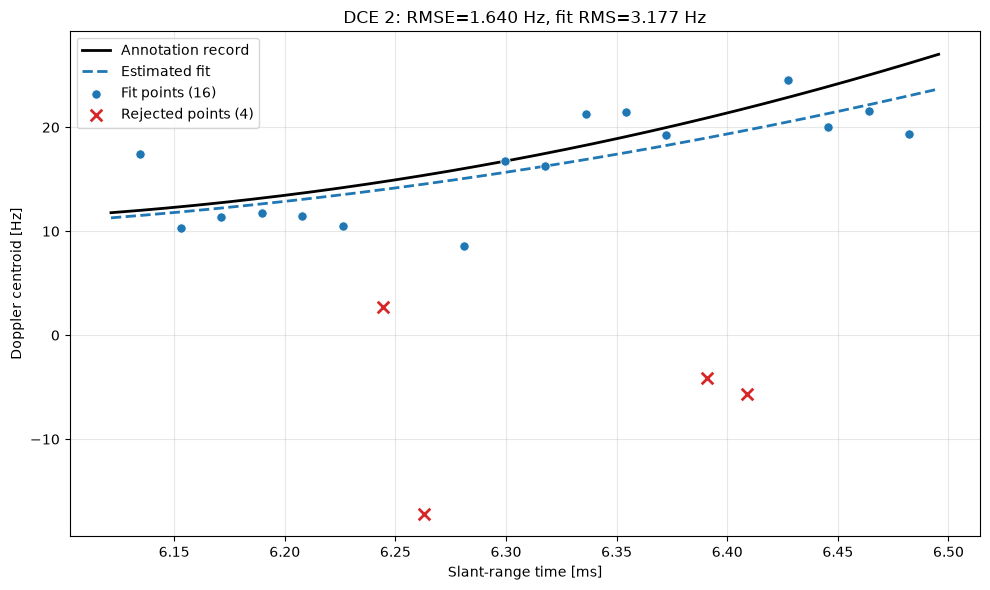

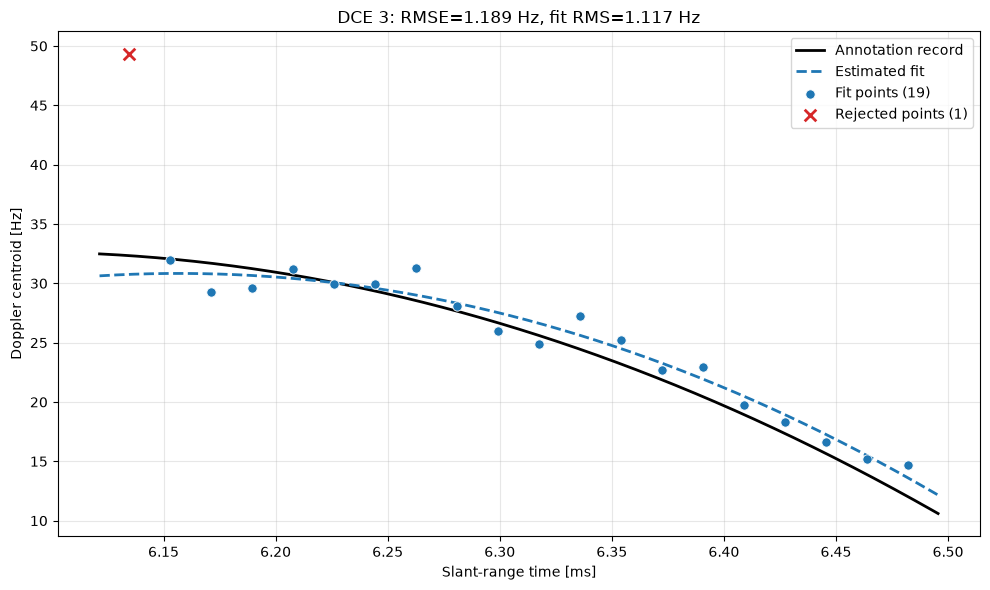

In [30]:
dce_figures = dce_plotting.plot_comparisons(doppler_centroid_comparisons)
plt.show()


#### Error summary

In [31]:
print(
    "Mean RMSE:", doppler_centroid_accuracy["rmse_hz"].mean(), "Hz |",
    "Worst max abs error:", doppler_centroid_accuracy["max_abs_error_hz"].max(), "Hz",
)
print(
    "Absolute ambiguity resolved:",
    doppler_centroid_accuracy["absolute_ambiguity_resolved"].all(),
    "(False is expected without a geometry DC provider)",
)


Mean RMSE: 2.3446916055939107 Hz | Worst max abs error: 10.427332604913488 Hz
Absolute ambiguity resolved: False (False is expected without a geometry DC provider)


## 8 - Effective velocity (DAD §9.10)

Use the L0 orbit records to calculate effective velocity for each processing block. Time checks are handled by the Python API.

### 8.1 - Orbit model

In [32]:
effective_velocity_estimator = effective_velocity.Estimator.from_level0_product(
    l0file, wavelength_m
)
effective_velocity_estimator.validate_time_coverage(packet_azimuth_times_s)


### 8.2 - Orbit time interval

In [33]:
pd.Series({
    "orbit_epochs": effective_velocity_estimator.orbit_times_s.size,
    "orbit_start_gps_s": effective_velocity_estimator.orbit_times_s[0],
    "orbit_stop_gps_s": effective_velocity_estimator.orbit_times_s[-1],
    "echo_start_gps_s": packet_azimuth_times_s[0],
    "echo_stop_gps_s": packet_azimuth_times_s[-1],
})


orbit_epochs         3.100000e+01
orbit_start_gps_s    1.450821e+09
orbit_stop_gps_s     1.450821e+09
echo_start_gps_s     1.450821e+09
echo_stop_gps_s      1.450821e+09
dtype: float64

### 8.3 - Effective velocity check

Use the 1398 Hz Stripmap S6 azimuth bandwidth from AUX_PP1.

In [34]:
AZIMUTH_PROCESSING_BANDWIDTH_HZ = 1398.0
velocity_check_index = len_az_line // 2
velocity_check = effective_velocity_estimator.evaluate_block(
    block_center_time_s=packet_azimuth_times_s[velocity_check_index],
    slant_range_m=slant_range_vec_m,
    fdc_hz=doppler_centroid_for_block(velocity_check_index),
    azimuth_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
    n_control_points=9,
    range_polynomial_degree=2,
    return_diagnostics=True,
)


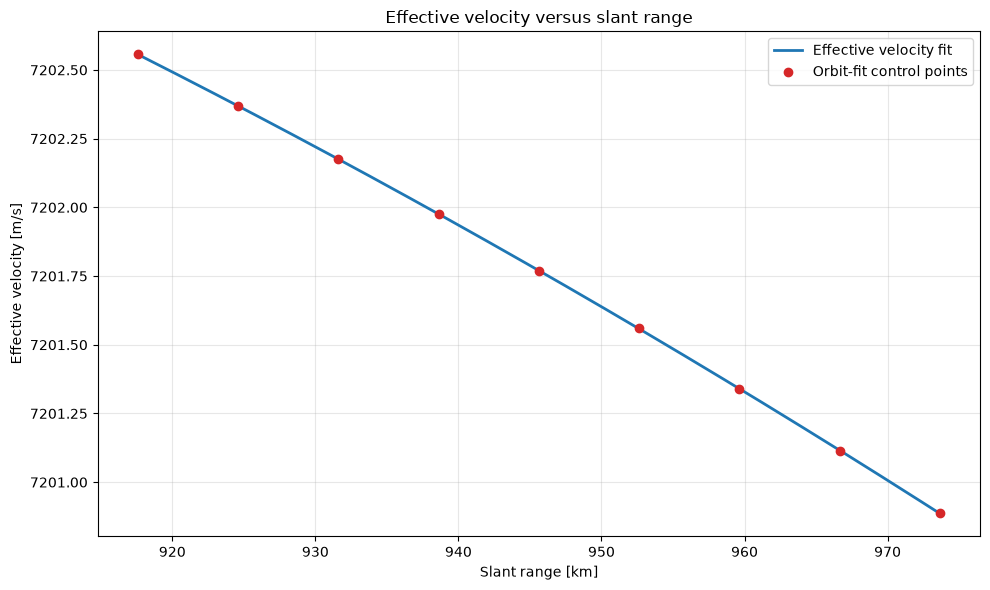

In [35]:
effective_velocity_figure = dce_plotting.plot_effective_velocity(
    slant_range_vec_m, velocity_check
)
plt.show()

pd.Series({
    "near_range_mps": velocity_check.vr_mps[0],
    "mid_range_mps": velocity_check.vr_mps[len_range_line // 2],
    "far_range_mps": velocity_check.vr_mps[-1],
    "max_fit_rms_m": max(
        point.fit_rms_m for point in velocity_check.control_points
    ),
})
del velocity_check


## 9 - Azimuth processing blocks (DAD §§9.12–9.13)

Set the azimuth bandwidth and calculate the matched-filter support, overlap, and block step.

### 9.1 - Processing parameters

In [36]:
FOCUS_FFT_LEN = 4096
EXTRA_AZIMUTH_PROCESSING_BLOCK_OVERLAP = 50


### 9.2 - Block layout

In [37]:
azimuth_block_layout = azimuth_processing.processing_blocks.calculate_layout(
    len_az_line,
    slant_range_vec_m,
    packet_azimuth_times_s,
    doppler_centroid_for_block,
    effective_velocity_estimator,
    wavelength_m=wavelength_m,
    azimuth_sample_frequency_hz=az_sample_freq,
    processing_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
    fft_length=FOCUS_FFT_LEN,
    extra_overlap_samples=EXTRA_AZIMUTH_PROCESSING_BLOCK_OVERLAP,
)


In [38]:
pd.Series({
    "support_samples": azimuth_block_layout.matched_filter_support_samples,
    "overlap_samples": azimuth_block_layout.overlap_samples,
    "step_samples": azimuth_block_layout.step_samples,
})


support_samples    1212
overlap_samples    1262
step_samples       2834
dtype: int64

## 10 - Azimuth Processing (DAD §6.3)

Stripmap S6 steps: SRC → RCMC → azimuth compression. Range resampling (§6.3.3) is only used for TOPSAR.

### 10.1 - Secondary Range Compression (DAD §6.3.1)

`azimuth_processing.secondary_range_compression.apply()` applies SRC in the range-Doppler domain.


In [39]:
SRC_SEGMENT_SAMPLES = 1024


### 10.2 - Range Cell Migration Correction (DAD §6.3.2)

`azimuth_processing.range_cell_migration_correction.apply()` uses sinc interpolation.


In [40]:
RCMC_KERNEL_LENGTH = 16
RCMC_NUM_PHASES = 64


### 10.3 - Azimuth Compression (DAD §6.3.4)

`azimuth_processing.azimuth_compression` exposes `calculate_matched_filter()`, `calculate_time_correction_filter()`, `apply_filters()`, and `inverse_fft()`. `compress()` runs them in order. The time correction is zero until fine bistatic and instrument timing values are supplied.


In [41]:
AZIMUTH_TIME_CORRECTION_S = 0.0


In [ ]:
focused_image = azimuth_processing.processing_blocks.focus_slc(
    range_compressed,
    slant_range_vec_m,
    packet_azimuth_times_s,
    doppler_centroid_for_block,
    effective_velocity_estimator,
    azimuth_block_layout,
    wavelength_m=wavelength_m,
    speed_of_light_mps=c,
    azimuth_sample_period_s=az_sample_period,
    range_sample_period_s=range_sample_period,
    range_sample_frequency_hz=range_sample_freq,
    processing_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
    fft_length=FOCUS_FFT_LEN,
    azimuth_time_correction_s=AZIMUTH_TIME_CORRECTION_S,
    src_segment_samples=SRC_SEGMENT_SAMPLES,
    rcmc_kernel_length=RCMC_KERNEL_LENGTH,
    rcmc_phases=RCMC_NUM_PHASES,
)


## 11 - Focused SLC output (DAD §9.12)

Keep the valid lines from each focused block and write them to the SLC.

In [ ]:
del range_compressed
pd.Series({"slc_shape": focused_image.shape})


## 12 - Display focused image

### 12.1 - Display scale

In [ ]:
tx_replica_sample_count = int(np.ceil(TXPL * range_sample_freq))
display_amplitude_scale = np.sqrt(tx_replica_sample_count)
valid_range_start = int(np.rint(
    (slant_range_time_vec_s[0] - raw_slant_range_time_vec_s[0])
    * range_sample_freq
))


### 12.2 - Full SLC image

In [ ]:
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Processed SAR Image")
plt.imshow(
    np.abs(focused_image[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm(
        vmin=300 / display_amplitude_scale,
        vmax=10000 / display_amplitude_scale,
    ),
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


### 12.3 - Detail view

In [ ]:
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Processed SAR Image - detail")
plt.imshow(
    np.abs(focused_image[
        9000:11000,
        6000 - valid_range_start:8000 - valid_range_start,
    ]),
    origin="lower",
    norm=colors.LogNorm(
        vmin=300 / display_amplitude_scale,
        vmax=10000 / display_amplitude_scale,
    ),
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


### 12.4 - Runtime

In [ ]:
elapsed = perf_counter() - notebook_started_at
print(f"Total runtime: {elapsed:.2f} s ({elapsed / 60:.2f} min)")


## 13 - Export amplitude TIFF for SNAP comparison

In [ ]:
# %pip install -q tifffile

# import tifffile

# tiff_path = "simple_focused_amplitude_raw_grid.tif"
# tiff = tifffile.memmap(
#     tiff_path,
#     shape=(len_az_line, raw_len_range_line),
#     dtype=np.float32,
#     bigtiff=True,
#     photometric="minisblack",
# )

# tiff[:, :valid_range_start] = np.nan
# tiff[:, valid_range_start + len_range_line:] = np.nan
# export_chunk_lines = 512
# for a0 in range(0, len_az_line, export_chunk_lines):
#     a1 = min(a0 + export_chunk_lines, len_az_line)
#     tiff[a0:a1, valid_range_start:valid_range_start + len_range_line] = np.abs(focused_image[a0:a1])

# tiff.flush()
# del tiff
# print("Saved for SNAP:", tiff_path)
